--- Primeras filas de datos con ruido Uniforme ---
          X         Y         Z
0 -0.434593 -1.152057  0.069464
1  1.561274  1.342278  2.645059
2  0.803627  2.450052  4.635104
3  0.341753 -0.474035 -1.759513
4 -1.191551 -1.009013 -2.174539


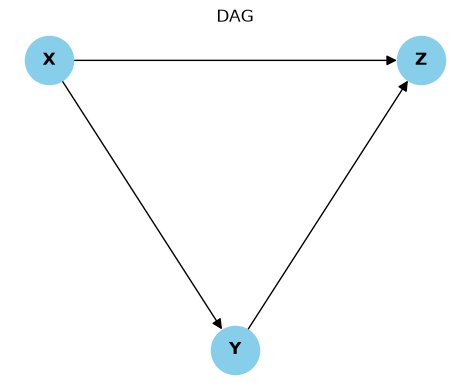

In [4]:
# ==============================================================================
# BLOQUE 1: GENERACIÓN DE DATOS SINTÉTICOS PARA EL TRIÁNGULO NO LINEAL
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import time
import re
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# 1. Definición del Grafo (X -> Y -> Z y X -> Z)
graph_triangle = nx.DiGraph([
    ('X', 'Y'),
    ('X', 'Z'),
    ('Y', 'Z')
])
# 2. Generación del SCM No Lineal Verdadero con RUIDO UNIFORME
def generate_synthetic_triangle_data_uniform(num_samples=2000, seed=42):
    np.random.seed(seed)
    
    # Definimos los límites para que la varianza sea 1.0
    # Varianza de una uniforme = (high - low)^2 / 12. 
    # Para varianza = 1, (high - low) debe ser sqrt(12) ≈ 3.464
    # Usamos [-1.732, 1.732]
    low, high = -1.732, 1.732
    
    # RUIDO UNIFORME
    eps_X = np.random.uniform(low, high, num_samples)
    eps_Y = np.random.uniform(low, high, num_samples)
    eps_Z = np.random.uniform(low, high, num_samples)
    
    # Ecuaciones del SCM (Se mantienen igual)
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

# Crear el DataFrame con ruido uniforme
data_triangle = generate_synthetic_triangle_data_uniform(num_samples=2000)

print("--- Primeras filas de datos con ruido Uniforme ---")
print(data_triangle.head())

# 3. Partición de datos (50% Train / 50% Eval) y Normalización
factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)

# Mapeo de tipos requerido por la arquitectura kan_model_mixed
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {} # Todo es puramente continuo

# Pintar el grafo estructural 
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG")
plt.show()

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.models.kan import hsic_loss, kan_model_mixed

# Definimos las betas que queremos probar
betas_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
results_by_beta = {}

for beta in betas_to_test:
    print(f"--- Entrenando con Beta: {beta} ---")
    
    # 1. Configuramos el hiperparámetro
    kan.hyperparameters['beta_weight'] = beta
    
    # 2. Llamada a la función SIN el ...
    # Asegúrate de incluir los parámetros obligatorios que tu función custom_fit espera
    results, train_loss_all = kan.custom_fit(
        dataset=dataset, 
        steps=100, 
        lamb=0.0, 
        lr=0.01, 
        batch=32  # Asegúrate de poner aquí los valores reales que usas normalmente
    )
    
    # 3. Guardamos la historia
    results_by_beta[beta] = train_loss_all

# --- FINALIZADO EL ENTRENAMIENTO DE TODAS LAS BETAS ---

plt.figure(figsize=(12, 7))

for beta, loss_history in results_by_beta.items():
    # Convertimos a serie para suavizar
    series = pd.Series(loss_history)
    smoothed = series.rolling(window=50).mean()
    
    # Pintamos
    plt.plot(smoothed, label=f'Beta = {beta}', alpha=0.8)

plt.yscale('log')
plt.title('Evolución de la Loss según el peso Beta')
plt.xlabel('Batches')
plt.ylabel('Loss (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

--- Entrenando con Beta: 0.1 ---


NameError: name 'kan' is not defined

In [3]:
import os
import gc
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# Asegúrate de tener estas librerías instaladas

base_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if base_path not in sys.path:
    sys.path.append(base_path)
    
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed
import networkx as nx
from copy import deepcopy

# 1. Definir el Grafo (Estructura Causal)
# Ajusta este grafo a tus necesidades. Ejemplo: X -> Y
graph = nx.DiGraph()
graph.add_edges_from([('X', 'Y')])

# 2. Configurar los parámetros por nodo
# Definimos los tipos de variables y los parámetros de la KAN
node_types = {'X': 'continuous', 'Y': 'continuous'}
base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 
    'lr': 0.002, 'early_stop': True, 'steps': 500, 'lamb': 0.05
}

# 3. Crear la estructura de parámetros que espera kan_model_mixed
# Esta estructura debe tener una entrada para cada nodo del grafo
params = {}
for nodo in graph.nodes():
    params[nodo] = deepcopy(base_kan_params)
    params[nodo]['node_types'] = node_types
    # Opcional: configurar loss si es necesario
    params[nodo]['loss'] = 'mse' 

# Ahora, el bucle de entrenamiento debería encontrar 'graph' y 'params' definidos

# --- 1. CONFIGURACIÓN ---
valores_N = [ 100, 500]
semillas = [155, 300]
historiales_loss = [] # Aquí guardaremos la evolución de la loss

# Hiperparámetros (Ejemplo)
base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'lr': 0.002,
    'early_stop': True, 'steps': 100, 'lamb': 0.05, 'loss': 'mse'
}

# --- 2. BUCLE PRINCIPAL DE ENTRENAMIENTO ---
for seed in semillas:
    print(f"Iniciando semilla: {seed}")
    for N in valores_N:
        # Generación de datos (Simulación)
        np.random.seed(seed)
        X = np.random.normal(size=N)
        Y = 0.5 * (X**2) + np.random.normal(size=N)
        data = pd.DataFrame({'X': X, 'Y': Y})
        train, test = train_test_split(data, test_size=0.5)

        # Entrenamiento
        model = kan_model_mixed(graph, params) # Asume que 'graph' y 'params' están definidos
        results = model.fit(train) # Asumimos que model.fit retorna un diccionario con 'train_loss'
        
        # Guardar historial para graficar
        historiales_loss.append({
            'seed': seed, 'N': N, 'loss': results['train_loss']
        })
        
        # Limpieza de memoria
        del model
        gc.collect()
        torch.cuda.empty_cache()

# --- 3. FUNCIÓN DE VISUALIZACIÓN ---
def plot_loss(historiales, n_filtro):
    plt.figure(figsize=(10, 5))
    for h in historiales:
        if h['N'] == n_filtro:
            plt.plot(h['loss'], alpha=0.5, label=f"Semilla {h['seed']}")
    plt.title(f"Evolución de la Loss de Entrenamiento (N={n_filtro})")
    plt.xlabel("Pasos")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# Ejecutar gráfico
plot_loss(historiales_loss, n_filtro=50)

ModuleNotFoundError: No module named 'src'